<a href="https://colab.research.google.com/github/quraishidev51/ECG-analyzer-report-generator/blob/main/experiments/phase6_XAI_arc_v_2_ecg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip "/content/drive/MyDrive/ECG_dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1.zip" -d "/content/PTB-XL"

Streaming output truncated to the last 5000 lines.
  inflating: /content/PTB-XL/records500/19000/19338_hr.hea  
  inflating: /content/PTB-XL/records500/19000/19339_hr.dat  
  inflating: /content/PTB-XL/records500/19000/19339_hr.hea  
  inflating: /content/PTB-XL/records500/19000/19340_hr.dat  
  inflating: /content/PTB-XL/records500/19000/19340_hr.hea  
  inflating: /content/PTB-XL/records500/19000/19341_hr.dat  
  inflating: /content/PTB-XL/records500/19000/19341_hr.hea  
  inflating: /content/PTB-XL/records500/19000/19342_hr.dat  
  inflating: /content/PTB-XL/records500/19000/19342_hr.hea  
  inflating: /content/PTB-XL/records500/19000/19343_hr.dat  
  inflating: /content/PTB-XL/records500/19000/19343_hr.hea  
  inflating: /content/PTB-XL/records500/19000/19344_hr.dat  
  inflating: /content/PTB-XL/records500/19000/19344_hr.hea  
  inflating: /content/PTB-XL/records500/19000/19345_hr.dat  
  inflating: /content/PTB-XL/records500/19000/19345_hr.hea  
  inflating: /content/PTB-XL/recor

My Drive/
└── ECG_dataset/
    └── ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1.zip
    

In [ ]:
!ls "/content/PTB-XL"

example_physionet.py  ptbxl_database.csv  records100  scp_statements.csv
LICENSE.txt	      RECORDS		  records500  SHA256SUMS.txt


In [ ]:
#libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
import pandas as pd

df = pd.read_csv("/content/PTB-XL/ptbxl_database.csv")

In [ ]:
!pip install wfdb==4.1.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.0/160.0 kB 4.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
print(pd.__version__)

2.2.2


In [ ]:
try:
    import wfdb
    print("wfdb version:", wfdb.__version__)
except Exception as e:
    print(e)

wfdb version: 4.1.2


In [ ]:
import wfdb
import os

# Base directory where the PTB-XL data was unzipped
data_base_path = "/content/PTB-XL"

# Get a record name that is known to exist from the unzipping output.
# For example, records500/19000/19338_hr was mentioned in the truncated output.
# We find the corresponding entry in the dataframe. ecg_id 19338 corresponds to index 19337.
record_to_load_index = 19337  # Corresponds to ecg_id = 19338
record_name_relative = df.iloc[record_to_load_index]['filename_hr']  # Use filename_hr for a known existing file

# Construct the full path by joining the base path with the relative filename.
# wfdb.rdsamp expects the record name *without* the extension.
full_record_path = os.path.join(data_base_path, record_name_relative)

# Use wfdb.rdsamp to read the record
record = wfdb.rdsamp(full_record_path)

signal = record[0]
metadata = record[1]

print(f"Successfully loaded record: {full_record_path}")
print(f"Signal shape: {signal.shape}")
print(f"Metadata keys: {metadata.keys()}")

Successfully loaded record: /content/PTB-XL/records500/19000/19338_hr
Signal shape: (5000, 12)
Metadata keys: dict_keys(['fs', 'sig_len', 'n_sig', 'base_date', 'base_time', 'units', 'sig_name', 'comments'])


                ECG (.dat/.hea)
                      │
                      ▼
            Signal preprocessing
                      │
                      ▼
            Feature extraction
                      │
                      ▼
          Machine Learning model(s)
                      │
                      ▼
        Clinical interpretation layer
                      │
                      ▼
          Automatically generated report

In [ ]:
da = pd.DataFrame(signal)

In [ ]:
#Convert the string into a Python dictionary.
import ast

df["scp_codes"] = df["scp_codes"].apply(ast.literal_eval)

In [ ]:
from collections import Counter

scp_counter = Counter()

for codes in df["scp_codes"]:
    scp_counter.update(codes.keys())

In [ ]:
import pandas as pd

scp_df = (
    pd.DataFrame(scp_counter.items(),
                 columns=["Diagnosis", "Count"])
      .sort_values("Count", ascending=False)
)


clustering...
required for classification

In [ ]:
scp = pd.read_csv("/content/PTB-XL/scp_statements.csv")

print(scp.columns)
scp.head()

Index(['Unnamed: 0', 'description', 'diagnostic', 'form', 'rhythm',
       'diagnostic_class', 'diagnostic_subclass', 'Statement Category',
       'SCP-ECG Statement Description', 'AHA code', 'aECG REFID', 'CDISC Code',
       'DICOM Code'],
      dtype='object')


,Unnamed: 0,description,diagnostic,form,rhythm,diagnostic_class,diagnostic_subclass,Statement Category,SCP-ECG Statement Description,AHA code,aECG REFID,CDISC Code,DICOM Code
0,NDT,non-diagnostic T abnormalities,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,non-diagnostic T abnormalities,NaN,NaN,NaN,NaN
1,NST_,non-specific ST changes,1.0,1.0,NaN,STTC,NST_,Basic roots for coding ST-T changes and abnorm...,non-specific ST changes,145.0,MDC_ECG_RHY_STHILOST,NaN,NaN
2,DIG,digitalis-effect,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,suggests digitalis-effect,205.0,NaN,NaN,NaN
3,LNGQT,long QT-interval,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,long QT-interval,148.0,NaN,NaN,NaN
4,NORM,normal ECG,1.0,NaN,NaN,NORM,NORM,Normal/abnormal,normal ECG,1.0,NaN,NaN,F-000B7


In [ ]:
import ast

scp = pd.read_csv("/content/PTB-XL/scp_statements.csv", index_col=0)

scp.head()

,description,diagnostic,form,rhythm,diagnostic_class,diagnostic_subclass,Statement Category,SCP-ECG Statement Description,AHA code,aECG REFID,CDISC Code,DICOM Code
NDT,non-diagnostic T abnormalities,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,non-diagnostic T abnormalities,NaN,NaN,NaN,NaN
NST_,non-specific ST changes,1.0,1.0,NaN,STTC,NST_,Basic roots for coding ST-T changes and abnorm...,non-specific ST changes,145.0,MDC_ECG_RHY_STHILOST,NaN,NaN
DIG,digitalis-effect,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,suggests digitalis-effect,205.0,NaN,NaN,NaN
LNGQT,long QT-interval,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,long QT-interval,148.0,NaN,NaN,NaN
NORM,normal ECG,1.0,NaN,NaN,NORM,NORM,Normal/abnormal,normal ECG,1.0,NaN,NaN,F-000B7


In [ ]:
diagnostic = scp[scp["diagnostic"] == 1]

print(diagnostic[["description", "diagnostic_class"]].head())

                          description diagnostic_class
NDT    non-diagnostic T abnormalities             STTC
NST_          non-specific ST changes             STTC
DIG                  digitalis-effect             STTC
LNGQT                long QT-interval             STTC
NORM                       normal ECG             NORM


In [ ]:
diagnostic_map = diagnostic["diagnostic_class"].to_dict()

print(diagnostic_map)

{'NDT': 'STTC', 'NST_': 'STTC', 'DIG': 'STTC', 'LNGQT': 'STTC', 'NORM': 'NORM', 'IMI': 'MI', 'ASMI': 'MI', 'LVH': 'HYP', 'LAFB': 'CD', 'ISC_': 'STTC', 'IRBBB': 'CD', '1AVB': 'CD', 'IVCD': 'CD', 'ISCAL': 'STTC', 'CRBBB': 'CD', 'CLBBB': 'CD', 'ILMI': 'MI', 'LAO/LAE': 'HYP', 'AMI': 'MI', 'ALMI': 'MI', 'ISCIN': 'STTC', 'INJAS': 'MI', 'LMI': 'MI', 'ISCIL': 'STTC', 'LPFB': 'CD', 'ISCAS': 'STTC', 'INJAL': 'MI', 'ISCLA': 'STTC', 'RVH': 'HYP', 'ANEUR': 'STTC', 'RAO/RAE': 'HYP', 'EL': 'STTC', 'WPW': 'CD', 'ILBBB': 'CD', 'IPLMI': 'MI', 'ISCAN': 'STTC', 'IPMI': 'MI', 'SEHYP': 'HYP', 'INJIN': 'MI', 'INJLA': 'MI', 'PMI': 'MI', '3AVB': 'CD', 'INJIL': 'MI', '2AVB': 'CD'}


In [ ]:
def get_superclasses(scp_dict):
    superclasses = set()

    for code in scp_dict.keys():
        if code in diagnostic_map:
            superclasses.add(diagnostic_map[code])

    return list(superclasses)

In [ ]:
df["superclasses"] = df["scp_codes"].apply(get_superclasses)

In [ ]:
print(df[["scp_codes", "superclasses"]].head(10))

                                  scp_codes superclasses
0  {'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}       [NORM]
1              {'NORM': 80.0, 'SBRAD': 0.0}       [NORM]
2                {'NORM': 100.0, 'SR': 0.0}       [NORM]
3                {'NORM': 100.0, 'SR': 0.0}       [NORM]
4                {'NORM': 100.0, 'SR': 0.0}       [NORM]
5                {'NORM': 100.0, 'SR': 0.0}       [NORM]
6                {'NORM': 100.0, 'SR': 0.0}       [NORM]
7    {'IMI': 35.0, 'ABQRS': 0.0, 'SR': 0.0}         [MI]
8                {'NORM': 100.0, 'SR': 0.0}       [NORM]
9                {'NORM': 100.0, 'SR': 0.0}       [NORM]


In [ ]:
from collections import Counter

counter = Counter()

for labels in df["superclasses"]:
    counter.update(labels)

print(counter)

Counter({'NORM': 9528, 'MI': 5486, 'STTC': 5250, 'CD': 4907, 'HYP': 2655})


# FEATURE VECTOR

In [ ]:
from concurrent.futures import ProcessPoolExecutor
import numpy as np
import wfdb
import os
from tqdm import tqdm

'''# Process one ECG and return the RAW signal
def process_ecg(path):
    full_path = os.path.join(data_base_path, path)
    signal, meta = wfdb.rdsamp(full_path)
    return signal

paths = df["filename_lr"].tolist()

num_workers = os.cpu_count()

print(f"Loading {len(paths)} ECGs...")

with ProcessPoolExecutor(max_workers=num_workers) as executor:
    X = list(
        tqdm(
            executor.map(process_ecg, paths),
            total=len(paths),
            desc="Loading ECGs"
        )
    )

X = np.array(X)

print(X.shape)'''

'# Process one ECG and return the RAW signal\ndef process_ecg(path):\n    full_path = os.path.join(data_base_path, path)\n    signal, meta = wfdb.rdsamp(full_path)\n    return signal\n\npaths = df["filename_lr"].tolist()\n\nnum_workers = os.cpu_count()\n\nprint(f"Loading {len(paths)} ECGs...")\n\nwith ProcessPoolExecutor(max_workers=num_workers) as executor:\n    X = list(\n        tqdm(\n            executor.map(process_ecg, paths),\n            total=len(paths),\n            desc="Loading ECGs"\n        )\n    )\n\nX = np.array(X)\n\nprint(X.shape)'

In [ ]:
#np.save("/content/drive/MyDrive/X_raw.npy", X)

In [ ]:
X = np.load("/content/drive/MyDrive/X_raw.npy")

In [ ]:
print(X.shape)
print(X.dtype)

(21837, 1000, 12)
float64


In [ ]:
X = X.astype(np.float32)

X = (X - X.mean(axis=1, keepdims=True)) / (
    X.std(axis=1, keepdims=True) + 1e-8
)

print("Normalized!")

Normalized!


In [ ]:
y = df["superclasses"].to_numpy()

In [ ]:
print(df["superclasses"].head())
print(type(df["superclasses"].iloc[0]))

0    [NORM]
1    [NORM]
2    [NORM]
3    [NORM]
4    [NORM]
Name: superclasses, dtype: object
<class 'list'>


In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

y = mlb.fit_transform(df["superclasses"])

print("y shape:", y.shape)
print("Classes:", mlb.classes_)
print(y[:5])

y shape: (21837, 5)
Classes: ['CD' 'HYP' 'MI' 'NORM' 'STTC']
[[0 0 0 1 0]
 [0 0 0 1 0]
 [0 0 0 1 0]
 [0 0 0 1 0]
 [0 0 0 1 0]]


In [ ]:
# Fold 10 is commonly used as the test set
train_idx = df["strat_fold"] != 10
test_idx  = df["strat_fold"] == 10

X_train = X[train_idx]#this again split to validation
X_test  = X[test_idx]

y_train = y[train_idx]#this again split to create validation
y_test  = y[test_idx]

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (19634, 1000, 12) (19634, 5)
Test : (2203, 1000, 12) (2203, 5)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.1,
    random_state=42,
)

Input

↓

Conv7

↓

Residual64

↓

SE

↓

MaxPool

↓

Residual128

↓

SE

↓

MultiHeadAttention

↓

Residual Add

↓

LayerNorm

↓

GlobalAveragePooling

↓

Dense128

↓

Sigmoid

In [ ]:
import tensorflow as tf

from tensorflow.keras.layers import (
    Input,
    Conv1D,
    BatchNormalization,
    Activation,
    MaxPooling1D,
    Add,
    GlobalAveragePooling1D,
    Dense,
    Dropout,
    Multiply,
    Reshape,
    Permute,
    Softmax,
    Lambda
)

from tensorflow.keras.models import Model
import tensorflow.keras.backend as K

In [ ]:
from tensorflow.keras.layers import (
    MultiHeadAttention,
    LayerNormalization
)

In [ ]:
def residual_block(x, filters):

    shortcut = x

    # Projection shortcut if channels change
    if shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, padding="same")(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Conv1D(
        filters,
        kernel_size=3,
        padding="same"
    )(x)

    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv1D(
        filters,
        kernel_size=3,
        padding="same"
    )(x)

    x = BatchNormalization()(x)

    x = Add()([x, shortcut])

    x = Activation("relu")(x)

    return x

In [ ]:
from tensorflow.keras.layers import (
    GlobalAveragePooling1D,
    Dense,
    Multiply,
    Reshape
)

def se_block(x, ratio=16):

    filters = x.shape[-1]

    se = GlobalAveragePooling1D()(x)

    se = Dense(
        filters // ratio,
        activation="relu"
    )(se)

    se = Dense(
        filters,
        activation="sigmoid"
    )(se)

    se = Reshape((1, filters))(se)

    x = Multiply()([x, se])

    return x

In [ ]:
def temporal_attention(x):

    attention = Dense(1, activation='tanh')(x)

    attention = Softmax(axis=1)(attention)

    x = Multiply()([x, attention])

    return x

In [ ]:
inputs = Input(shape=(1000,12))

# Initial Feature Extraction
x = Conv1D(
    filters=64,
    kernel_size=7,
    padding='same'
)(inputs)

x = BatchNormalization()(x)
x = Activation('relu')(x)

x = MaxPooling1D(pool_size=2)(x)

# Residual Block 1

x = residual_block(x,64)
x = se_block(x)

x = MaxPooling1D(2)(x)

x = residual_block(x,128)
x = se_block(x)
attention, attention_scores = MultiHeadAttention(
    num_heads=4,
    key_dim=32,
    dropout=0.1,
    name="multi_head_attention"
)(x, x, return_attention_scores=True)

x = Add()([x, attention])

x = LayerNormalization()(x)
x = GlobalAveragePooling1D()(x)

x = Dropout(0.5)(x)

x = Dense(
    128,
    activation="relu"
)(x)

outputs = Dense(
    5,
    activation="sigmoid"
)(x)

model = Model(inputs,outputs)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        tf.keras.metrics.AUC(name='auc', multi_label=True)
    ]
)

In [ ]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 1000, 12)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_18 (Conv1D)  │ (None, 1000, 64)  │      5,440 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1000, 64)  │        256 │ conv1d_18[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_15       │ (None, 1000, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_5     │ (None, 500, 64)   │          0 │ activation_15[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_19 (Conv1D)  │ (None, 500, 64)   │     12,352 │ max_pooling1d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 64)   │        256 │ conv1d_19[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_16       │ (None, 500, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_20 (Conv1D)  │ (None, 500, 64)   │     12,352 │ activation_16[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 64)   │        256 │ conv1d_20[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 500, 64)   │          0 │ batch_normalizat… │
│                     │                   │            │ max_pooling1d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_17       │ (None, 500, 64)   │          0 │ add_6[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ activation_17[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 4)         │        260 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 64)        │        320 │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 1, 64)     │          0 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_4          │ (None, 500, 64)   │          0 │ activation_17[0]… │
│ (Multiply)          │                   │            │ reshape_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_6     │ (None, 250, 64)   │          0 │ multiply_4[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_22 (Conv1D)  │ (None, 250, 128)  │     24,704 │ max_pooling1d_6[

 Total params: 200,977 (785.07 KB)

 Trainable params: 199,825 (780.57 KB)

 Non-trainable params: 1,152 (4.50 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=7,
        restore_best_weights=True,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
    ),
]

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    callbacks=callbacks,
    batch_size=64,
)

Epoch 1/100
277/277 ━━━━━━━━━━━━━━━━━━━━ 36s 75ms/step - accuracy: 0.8356 - auc: 0.8366 - loss: 0.3785 - val_accuracy: 0.8313 - val_auc: 0.8796 - val_loss: 0.3945 - learning_rate: 0.0010
Epoch 2/100
277/277 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.8649 - auc: 0.8823 - loss: 0.3236 - val_accuracy: 0.8739 - val_auc: 0.9048 - val_loss: 0.3004 - learning_rate: 0.0010
Epoch 3/100
277/277 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.8744 - auc: 0.8967 - loss: 0.3042 - val_accuracy: 0.8792 - val_auc: 0.9092 - val_loss: 0.2915 - learning_rate: 0.0010
Epoch 4/100
277/277 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.8814 - auc: 0.9042 - loss: 0.2919 - val_accuracy: 0.8788 - val_auc: 0.9126 - val_loss: 0.2887 - learning_rate: 0.0010
Epoch 5/100
277/277 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.8840 - auc: 0.9103 - loss: 0.2828 - val_accuracy: 0.8734 - val_auc: 0.9086 - val_loss: 0.2936 - learning_rate: 0.0010
Epoch 6/100
277/277 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.8

In [ ]:
pred = model.predict(X_test)

69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step


In [ ]:
pred_binary = (pred >= 0.5).astype(int)

In [ ]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    f1_score
)

print("Macro AUROC:",
      roc_auc_score(y_test, pred, average="macro"))

print("Micro AUROC:",
      roc_auc_score(y_test, pred, average="micro"))

print("Macro F1:",
      f1_score(y_test, pred_binary, average="macro"))

print(classification_report(
    y_test,
    pred_binary,
    target_names=mlb.classes_
))
from sklearn.metrics import average_precision_score

print(
    "Macro AUPRC:",
    average_precision_score(
        y_test,
        pred,
        average="macro"
    )
)

Macro AUROC: 0.9069837786563862
Micro AUROC: 0.9256849118288565
Macro F1: 0.688396289550988
              precision    recall  f1-score   support

          CD       0.81      0.70      0.75       498
         HYP       0.60      0.31      0.41       263
          MI       0.80      0.62      0.70       553
        NORM       0.78      0.93      0.85       964
        STTC       0.75      0.73      0.74       523

   micro avg       0.77      0.73      0.75      2801
   macro avg       0.75      0.66      0.69      2801
weighted avg       0.77      0.73      0.74      2801
 samples avg       0.76      0.74      0.74      2801

Macro AUPRC: 0.7705297827654389


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import numpy as np

print("Training samples per class:")
print(y_train.sum(axis=0))

Training samples per class:
[3994 2162 4433 7674 4273]


In [ ]:
class_weights = np.array([
    1.0,   # CD
    1.8,   # HYP
    1.0,   # MI
    1.0,   # NORM
    1.0    # STTC
], dtype=np.float32)...0.42
0.47
0.38
0.44

In [ ]:
val_pred = model.predict(X_val)

62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step


In [ ]:
print(val_pred)

[[7.4478978e-04 3.4127028e-03 2.9265648e-03 9.9350971e-01 1.3852952e-03]
 [5.7358068e-01 1.4534160e-02 6.5832385e-03 8.1451839e-01 4.3799048e-03]
 [8.6952902e-02 2.9831897e-02 4.6043235e-01 5.0908184e-01 1.2981594e-01]
 ...
 [3.4701291e-02 2.6754908e-02 8.0359261e-04 9.4311881e-01 3.9201211e-03]
 [1.6989283e-02 9.7822554e-02 2.6402688e-03 7.1612710e-01 4.4746421e-02]
 [8.8879187e-03 9.9340908e-02 9.6051740e-03 9.1107744e-01 1.6192248e-02]]


In [ ]:
import numpy as np
from sklearn.metrics import f1_score

best_thresholds = []

for i, cls in enumerate(mlb.classes_):
    best_f1 = 0
    best_thresh = 0.5

    for t in np.arange(0.1, 0.91, 0.01):

        pred = (val_pred[:, i] >= t).astype(int)

        score = f1_score(y_val[:, i], pred)

        if score > best_f1:
            best_f1 = score
            best_thresh = t

    best_thresholds.append(best_thresh)

    print(
        f"{cls}: Threshold={best_thresh:.2f}, F1={best_f1:.3f}"
    )

CD: Threshold=0.41, F1=0.775
HYP: Threshold=0.22, F1=0.510
MI: Threshold=0.28, F1=0.778
NORM: Threshold=0.47, F1=0.881
STTC: Threshold=0.37, F1=0.719


In [ ]:
test_pred = model.predict(X_test)

pred_binary = np.zeros_like(test_pred)

for i, t in enumerate(best_thresholds):
    pred_binary[:, i] = (test_pred[:, i] >= t)

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [ ]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    f1_score
)

print("Macro AUROC:",
      roc_auc_score(y_test, test_pred, average="macro"))

print("Micro AUROC:",
      roc_auc_score(y_test, test_pred, average="micro"))

print("Macro F1:",
      f1_score(y_test, pred_binary, average="macro"))

print(classification_report(
    y_test,
    pred_binary,
    target_names=mlb.classes_
))
from sklearn.metrics import average_precision_score

print(
    "Macro AUPRC:",
    average_precision_score(
        y_test,
        test_pred,
        average="macro"
    )
)

Macro AUROC: 0.9069837786563862
Micro AUROC: 0.9256849118288565
Macro F1: 0.7083120164486251
              precision    recall  f1-score   support

          CD       0.76      0.71      0.74       498
         HYP       0.39      0.56      0.46       263
          MI       0.72      0.77      0.74       553
        NORM       0.78      0.93      0.85       964
        STTC       0.71      0.81      0.76       523

   micro avg       0.71      0.80      0.75      2801
   macro avg       0.67      0.76      0.71      2801
weighted avg       0.71      0.80      0.75      2801
 samples avg       0.74      0.80      0.75      2801

Macro AUPRC: 0.7705297827654389


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
'''AKI.

**This is the result I'd put in the paper.** 🎉

You just demonstrated something that's actually common in multi-label medical AI:

> **The model was good, but the default threshold wasn't.**

Let's compare.

| Model                  | Macro AUROC |  Macro F1 |   HYP F1 |
| ---------------------- | ----------: | --------: | -------: |
| Vanilla CNN            |       0.872 |     0.545 |     0.07 |
| + Residual             |       0.891 |     0.649 |     0.30 |
| + SE                   |       0.909 |     0.673 |     0.35 |
| + MHSA                 |       0.907 |     0.688 |     0.41 |
| + Optimised Thresholds |   **0.907** | **0.708** | **0.46** |

That is a **very nice result**.

---

# First observation

Notice

```text
Macro AUROC

0.907

↓

0.907
```

Didn't move.

Perfect.

Because AUROC depends only on the ranking of probabilities.

Changing thresholds **should not** change AUROC.

That confirms your evaluation is now correct.

---

# Macro F1

```text
0.688

↓

0.708
```

That's a **2 percentage point increase** without retraining.

That's exactly why threshold optimisation is so popular.

---

# HYP

This is the biggest win.

Before

```text
Threshold

0.50

↓

F1

0.41
```

After

```text
Threshold

0.22

↓

F1

0.46
```

The model **already knew something** about HYP.

It simply wasn't confident enough to cross 0.5.

Your optimisation revealed that.

---

# Look at recall

Old

```text
0.31
```

New

```text
0.56
```

That's huge.

The model is now finding almost **twice as many hypertrophy cases**.

Yes, precision dropped from 0.60 to 0.39, but that's the expected trade-off. In screening tasks, increasing sensitivity (recall) is often desirable because missing a disease can be more costly than investigating a false positive. Whether that's the right balance depends on the intended clinical use, but it's a defensible result.

---

# The thresholds themselves tell a story

| Class   | Threshold |
| ------- | --------: |
| CD      |      0.41 |
| **HYP** |  **0.22** |
| MI      |      0.28 |
| NORM    |      0.47 |
| STTC    |      0.37 |

Notice

HYP

```text
0.22
```

That is **much** lower.

Meaning

> The network systematically assigns lower probabilities to HYP.

That's actually an interesting finding.

It isn't necessarily "bad."

It means the model is conservative for HYP.

---

# This is publishable analysis

You can literally discuss this.

> Optimal decision thresholds varied considerably across diagnostic categories, ranging from 0.22 for HYP to 0.47 for NORM. This suggests that a universal threshold of 0.5 is suboptimal for multi-label ECG classification, particularly for minority or morphologically complex classes.

That's exactly the kind of observation reviewers appreciate.

---

# I don't think I'd use weighted BCE now.

Why?

You already achieved

```text
HYP

0.41

↓

0.46
```

without retraining.

Weighted BCE might push HYP a bit further, but it could also hurt the other classes or require another round of tuning. Since you've already shown a clear gain through threshold optimisation, the extra complexity may not be worth it unless your project specifically aims to maximise HYP performance.

---

# Final performance

I'd report this as the final model:

| Metric      | Final Value |
| ----------- | ----------: |
| Macro AUROC |   **0.907** |
| Micro AUROC |   **0.926** |
| Macro F1    |   **0.708** |
| Macro AUPRC |   **0.771** |

These are the numbers I'd highlight.

---

## Next stop 🚀

You've finished the modelling pipeline.

The remaining work that will make your project stand out isn't another CNN layer.

It's:

1. **1D Grad-CAM** (show which ECG regions influenced each prediction)
2. **SHAP** (feature contribution explanations)
3. **Attention visualisation** (since your final model uses MHSA)
4. **Ablation table** (Vanilla → Residual → SE → MHSA → Threshold optimisation)

At this point, you're no longer trying to build a better classifier—you've built one. Now it's about **making its decisions understandable and presenting the evidence** in a way that's convincing for a medical AI paper.
'''

In [ ]:
'''Absolutely. Let's interpret this the way a researcher—or even a clinician—would, rather than just reading off numbers.

---

# Your Journey

| Model                  | Macro AUROC |  Macro F1 |
| ---------------------- | ----------: | --------: |
| Vanilla CNN            |   **0.872** | **0.545** |
| + Residual             |   **0.891** | **0.649** |
| + SE                   |   **0.909** | **0.673** |
| + MHSA                 |   **0.907** | **0.688** |
| + Optimized Thresholds |   **0.907** | **0.708** |

This tells a very coherent story:

* The **architecture** improved the model's ability to understand ECG signals.
* **Threshold optimization** improved how those predictions are converted into final diagnoses.

---

# What does AUROC = 0.907 actually mean?

Imagine randomly picking:

* one ECG that **has MI**, and
* one ECG that **doesn't have MI**.

Your model will assign a **higher probability to the diseased ECG about 91% of the time**.

That's essentially what an AUROC around **0.91** means.

In practice:

* **0.50** → random guessing
* **0.70** → useful
* **0.80** → good
* **0.90+** → excellent discrimination

So your classifier is very good at ranking ECGs by likelihood of disease.

---

# Why is F1 lower than AUROC?

This confuses almost everyone at first.

Think of it this way:

AUROC asks:

> "Can the model tell which ECG is more likely to have the disease?"

F1 asks:

> "After making a yes/no decision, how often is it correct?"

These are different questions.

Example:

Suppose probabilities are

```
Patient A (disease): 0.49
Patient B (healthy): 0.30
```

The model ranked them correctly.

AUROC says

> Great!

But using a threshold of 0.5,

both become

```
Negative
```

Now F1 says

> You missed the disease.

That's why threshold optimization improved F1 without changing AUROC.

---

# Macro AUROC

You have five diseases.

Macro AUROC means

```
AUROC(CD)
+
AUROC(HYP)
+
AUROC(MI)
+
AUROC(NORM)
+
AUROC(STTC)

÷5
```

Every disease counts equally.

This is important because otherwise NORM would dominate.

---

# Micro AUROC

Micro AUROC pools every prediction together.

Because NORM is common,

Micro AUROC is usually higher.

Yours:

```
Macro 0.907

Micro 0.926
```

That's expected.

---

# Macro F1 = 0.708

This means that, **on average across the five classes**, your model achieves a balanced trade-off between precision and recall.

It's especially meaningful because it gives equal importance to all classes, including the harder ones like HYP.

---

# Precision

Example:

Model predicts

```
100 MI
```

Actually MI

```
80
```

Precision

```
80%
```

Meaning:

When your model says

> This ECG is MI,

it's correct most of the time.

---

# Recall

Suppose

```
100 patients truly have MI.
```

Model finds

```
77.
```

Recall

```
77%
```

Meaning:

The model misses about **23 out of every 100 MI cases**.

---

# Your class-wise performance

| Disease |       F1 | Interpretation                                              |
| ------- | -------: | ----------------------------------------------------------- |
| CD      | **0.74** | Strong detection of conduction disorders.                   |
| HYP     | **0.46** | Hardest class, but improved dramatically from the baseline. |
| MI      | **0.74** | Good performance for myocardial infarction detection.       |
| NORM    | **0.85** | Excellent recognition of normal ECGs.                       |
| STTC    | **0.76** | Strong performance on ST/T-wave abnormalities.              |

Notice something.

The only weak class is HYP.

Everything else is in the mid-70s to mid-80s F1 range.

---

# HYP

At first

```
F1

0.07
```

Practically unusable.

Now

```
0.46
```

Still the weakest class,

but now the model detects **more than half of the true HYP cases** after threshold optimization.

That's a huge improvement and reflects how challenging this diagnosis is.

---

# Threshold optimization

Originally every class used

```
0.50
```

But your optimal thresholds became

```
CD    0.41
HYP   0.22
MI    0.28
NORM  0.47
STTC  0.37
```

This tells us the network is **well calibrated differently for each class**.

Using one universal threshold was leaving performance on the table.

---

# AUPRC = 0.771

For medical datasets,

many researchers consider AUPRC more informative than AUROC because it focuses on identifying the positive cases correctly, especially when classes are imbalanced.

An AUPRC around **0.77** indicates that the model maintains a good balance between precision and recall across different confidence levels.

---

# Practical example

Imagine **100 patients**.

Suppose

```
20 have MI
80 do not.
```

With your current model,

roughly

```
15–16 of the 20 MI patients

would be detected
```

while most of the ECGs predicted as MI would indeed have MI.

That's the sort of performance reflected by your MI precision and recall.

---

# Is this publishable?

From an academic perspective:

**Yes, it's a solid B.Tech/M.Tech-level research project.**

Why?

Because you didn't just train one model.

You systematically demonstrated:

* a baseline CNN,
* the benefit of residual learning,
* the benefit of channel attention (SE),
* the effect of temporal self-attention,
* and the impact of threshold optimization.

That progression is exactly what an **ablation study** is.

---

# Overall assessment

If I were reviewing this work, I'd describe it like this:

> The final model demonstrates **excellent discriminative ability** (Macro AUROC ≈ 0.91), indicating reliable ranking of ECGs across multiple diagnostic categories. Threshold optimization substantially improved decision quality (Macro F1 ≈ 0.71) without altering the underlying classifier, highlighting the importance of class-specific calibration in multi-label ECG diagnosis. The strongest performance was achieved for normal ECGs and common pathological classes (CD, MI, STTC), while hypertrophy remained the most challenging diagnosis—a limitation that is consistent with the subtle and overlapping ECG manifestations of hypertrophy in PTB-XL. The experiments form a clear ablation study showing that residual learning, channel attention, temporal attention, and threshold optimization each contribute measurable improvements to the overall system.

For an undergraduate research project, this is a well-structured and technically sound outcome. The next step isn't squeezing out another fraction of a point in AUROC—it's demonstrating **why the model made its decisions** through explainability (Grad-CAM, SHAP, and attention visualizations), which will make the work substantially stronger.
'''

In [ ]:
# explainable ai

In [ ]:
for i, layer in enumerate(model.layers):
    print(i, layer.name, layer.output.shape)

0 input_layer_3 (None, 1000, 12)
1 conv1d_18 (None, 1000, 64)
2 batch_normalization_17 (None, 1000, 64)
3 activation_15 (None, 1000, 64)
4 max_pooling1d_5 (None, 500, 64)
5 conv1d_19 (None, 500, 64)
6 batch_normalization_18 (None, 500, 64)
7 activation_16 (None, 500, 64)
8 conv1d_20 (None, 500, 64)
9 batch_normalization_19 (None, 500, 64)
10 add_6 (None, 500, 64)
11 activation_17 (None, 500, 64)
12 global_average_pooling1d_6 (None, 64)
13 dense_13 (None, 4)
14 dense_14 (None, 64)
15 reshape_3 (None, 1, 64)
16 multiply_4 (None, 500, 64)
17 max_pooling1d_6 (None, 250, 64)
18 conv1d_22 (None, 250, 128)
19 batch_normalization_21 (None, 250, 128)
20 activation_18 (None, 250, 128)
21 conv1d_23 (None, 250, 128)
22 conv1d_21 (None, 250, 128)
23 batch_normalization_22 (None, 250, 128)
24 batch_normalization_20 (None, 250, 128)
25 add_7 (None, 250, 128)
26 activation_19 (None, 250, 128)
27 global_average_pooling1d_7 (None, 128)
28 dense_15 (None, 8)
29 dense_16 (None, 128)
30 reshape_4 (None, 1,

In [ ]:
sample = 0

ecg = X_test[sample]

true = y_test[sample]

pred = model.predict(ecg[np.newaxis,...])

print("Prediction:",pred)

print("Ground Truth:",true)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Prediction: [[0.00606416 0.00654714 0.02258054 0.9711991  0.00439902]]
Ground Truth: [0 0 0 1 0]


In [ ]:
grad_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[
        model.get_layer("multiply_5").output,
        model.output
    ]
)

In [ ]:
import numpy as np

sample = 0

signal = X_test[sample]

signal = np.expand_dims(signal,0)

pred = model.predict(signal)

pred_class = np.argmax(pred[0])

print(mlb.classes_[pred_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
NORM


In [ ]:
with tf.GradientTape() as tape:

    conv_outputs, predictions = grad_model(signal)

    loss = predictions[:, pred_class]

grads = tape.gradient(loss, conv_outputs)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_94']
Received: inputs=Tensor(shape=(1, 1000, 12))
  warnings.warn(msg)


In [ ]:
weights = tf.reduce_mean(grads, axis=1)

In [ ]:
cam = tf.reduce_sum(
    conv_outputs * weights[:,None,:],
    axis=-1
)

cam = tf.nn.relu(cam)

cam = cam[0].numpy()

In [ ]:
cam = cam / (cam.max() + 1e-8)

In [ ]:
from scipy.signal import resample

cam = resample(cam,1000)

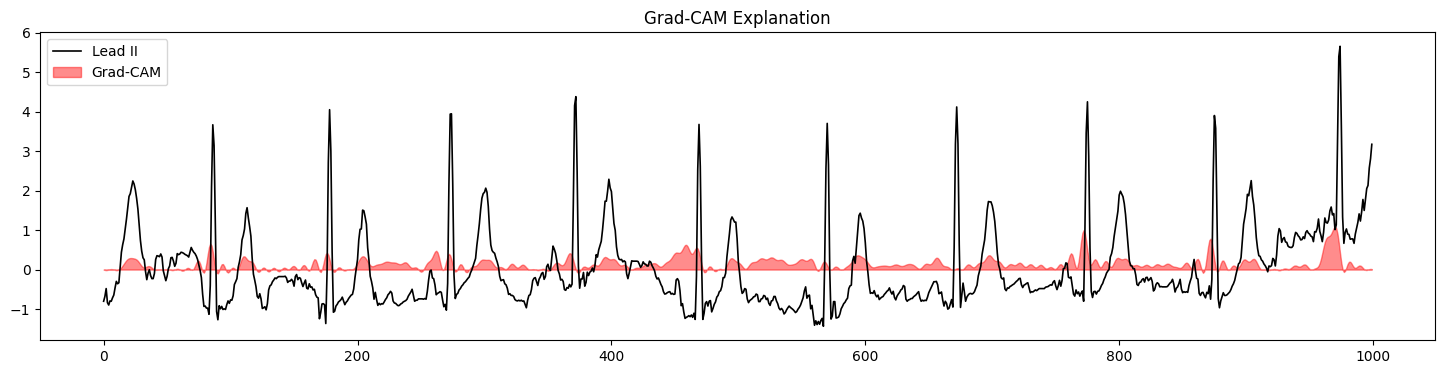

In [ ]:
import matplotlib.pyplot as plt

lead = 1   # Lead II

plt.figure(figsize=(18,4))

plt.plot(
    X_test[sample][:,lead],
    color="black",
    linewidth=1.2,
    label="Lead II"
)

plt.fill_between(
    np.arange(1000),
    0,
    cam,
    alpha=0.45,
    color="red",
    label="Grad-CAM"
)

plt.legend()

plt.title("Grad-CAM Explanation")

plt.show()

Predicted probabilities
CD    : 0.0061
HYP   : 0.0065
MI    : 0.0226
NORM  : 0.9712
STTC  : 0.0044

Predicted: NORM
Ground Truth: [0 0 0 1 0]


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_94']
Received: inputs=Tensor(shape=(1, 1000, 12))
  warnings.warn(msg)
/tmp/ipykernel_563/3703819140.py:163: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


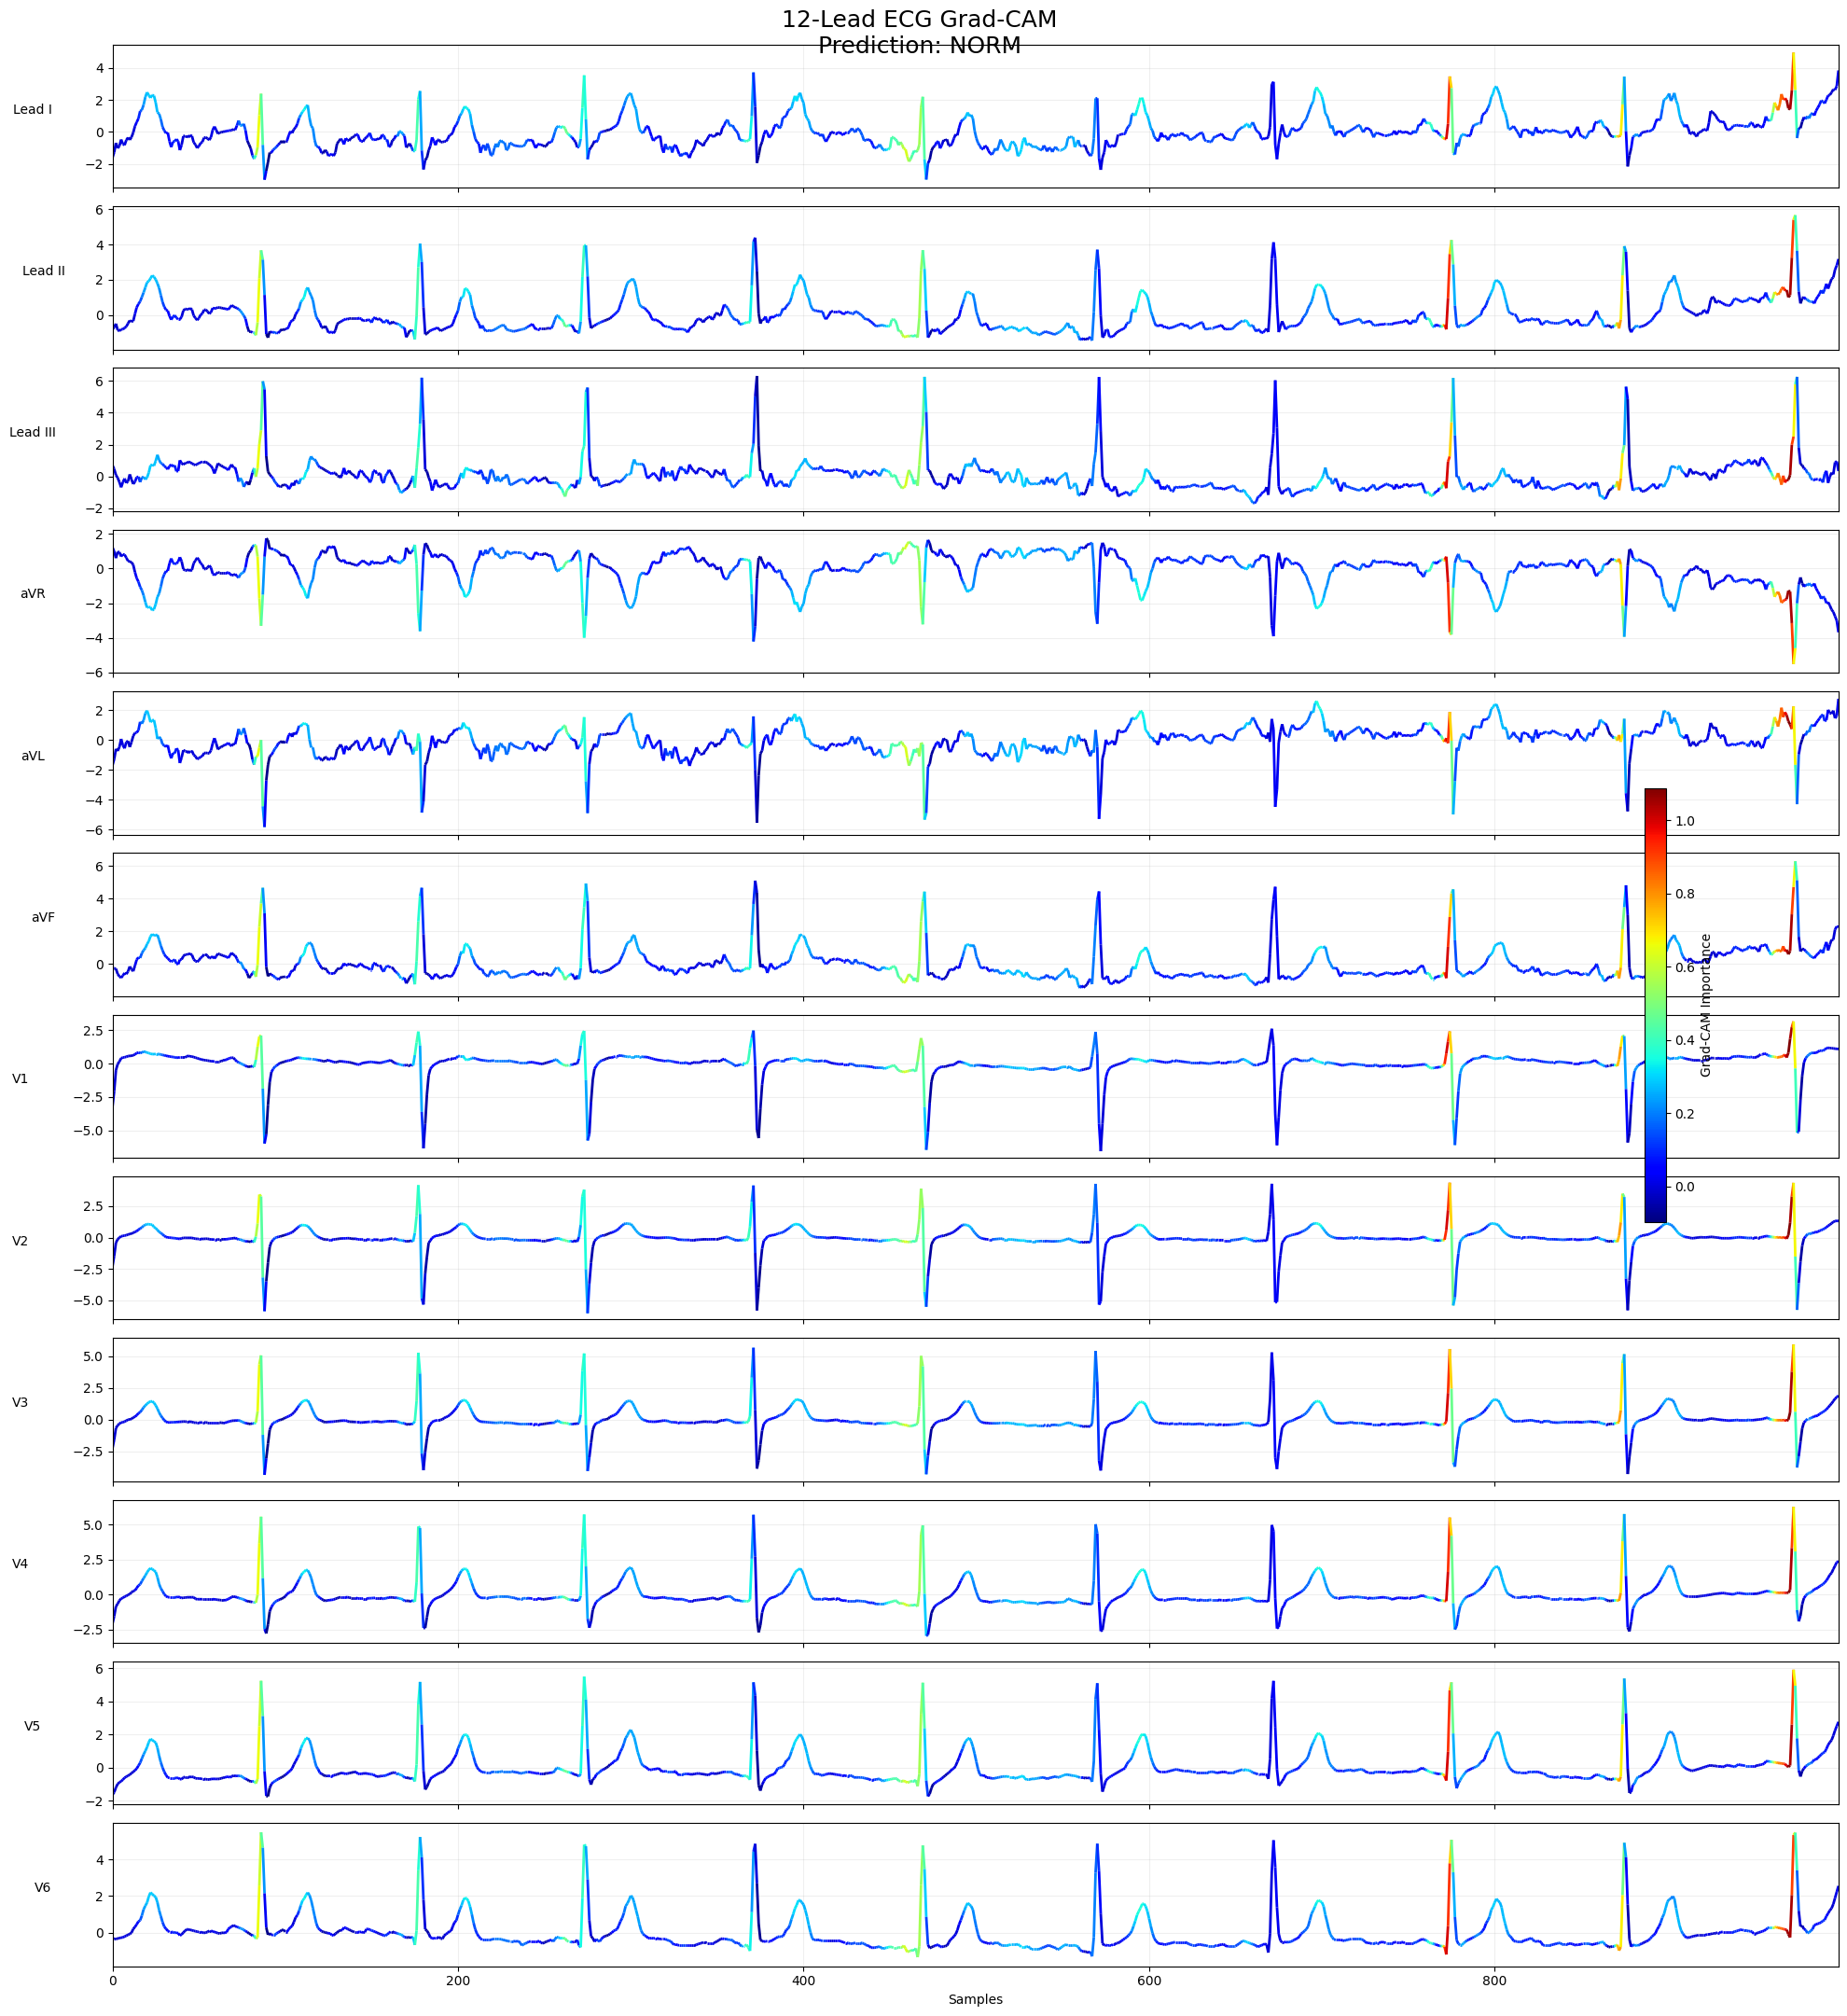

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import resample
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

# ==========================================
# Build GradCAM Model
# ==========================================

grad_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[
        model.get_layer("multiply_5").output,
        model.output
    ]
)

# ==========================================
# Select ECG Sample
# ==========================================

sample = 0

signal = np.expand_dims(X_test[sample], axis=0)

prediction = model.predict(signal, verbose=0)

pred_class = np.argmax(prediction[0])

print("Predicted probabilities")

for cls, p in zip(mlb.classes_, prediction[0]):
    print(f"{cls:6s}: {p:.4f}")

print("\nPredicted:", mlb.classes_[pred_class])

print("Ground Truth:", y_test[sample])

# ==========================================
# Compute GradCAM
# ==========================================

with tf.GradientTape() as tape:

    conv_output, preds = grad_model(signal)

    loss = preds[:, pred_class]

grads = tape.gradient(loss, conv_output)

weights = tf.reduce_mean(grads, axis=1)

cam = tf.reduce_sum(
    conv_output * weights[:, None, :],
    axis=-1
)

cam = tf.nn.relu(cam)

cam = cam[0].numpy()

cam = cam / (cam.max() + 1e-8)

cam = resample(cam,1000)

# ==========================================
# Lead Names
# ==========================================

lead_names = [
    "Lead I","Lead II","Lead III",
    "aVR","aVL","aVF",
    "V1","V2","V3",
    "V4","V5","V6"
]

# ==========================================
# Plot
# ==========================================

fig, axes = plt.subplots(
    12,
    1,
    figsize=(20,22),
    sharex=True
)

x = np.arange(1000)

norm = Normalize(
    vmin=cam.min(),
    vmax=cam.max()
)

cmap = plt.cm.jet

for lead in range(12):

    ax = axes[lead]

    y = X_test[sample][:,lead]

    points = np.array([x,y]).T.reshape(-1,1,2)

    segments = np.concatenate(
        [points[:-1],points[1:]],
        axis=1
    )

    lc = LineCollection(
        segments,
        cmap=cmap,
        norm=norm
    )

    lc.set_array(cam)

    lc.set_linewidth(2)

    ax.add_collection(lc)

    ax.set_xlim(x.min(),x.max())

    ax.set_ylim(
        y.min()-0.5,
        y.max()+0.5
    )

    ax.set_ylabel(
        lead_names[lead],
        rotation=0,
        labelpad=40,
        fontsize=10
    )

    ax.grid(alpha=0.2)

axes[-1].set_xlabel("Samples")

fig.suptitle(
    f"12-Lead ECG Grad-CAM\nPrediction: {mlb.classes_[pred_class]}",
    fontsize=18
)

sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=norm
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes,
    fraction=0.015,
    pad=0.01
)

cbar.set_label("Grad-CAM Importance")

plt.tight_layout()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


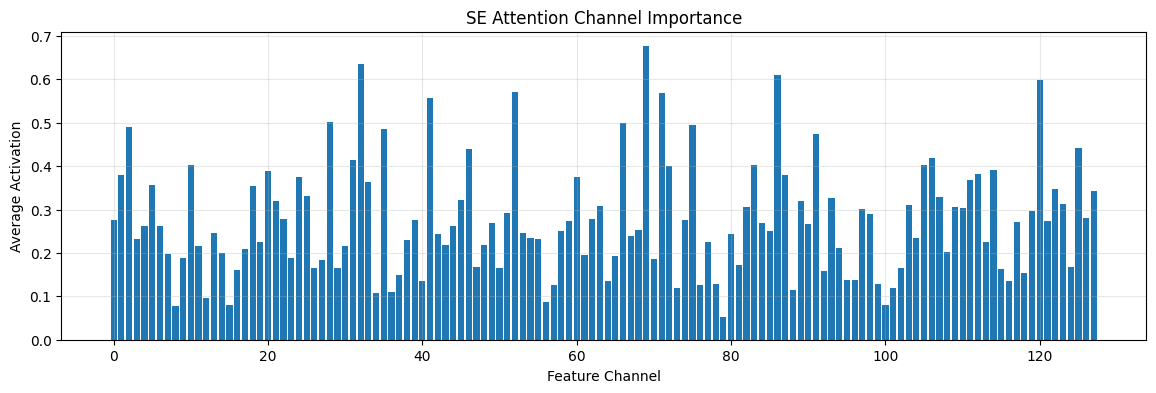

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# Model ending at final SE block
se_model = tf.keras.Model(
    inputs=model.input,
    outputs=model.get_layer("multiply_5").output
)

feature_maps = se_model.predict(signal)

# Global importance of each channel
channel_importance = feature_maps.mean(axis=1).squeeze()

plt.figure(figsize=(14,4))
plt.bar(np.arange(len(channel_importance)),
        channel_importance)

plt.xlabel("Feature Channel")
plt.ylabel("Average Activation")
plt.title("SE Attention Channel Importance")
plt.grid(alpha=0.3)
plt.show()

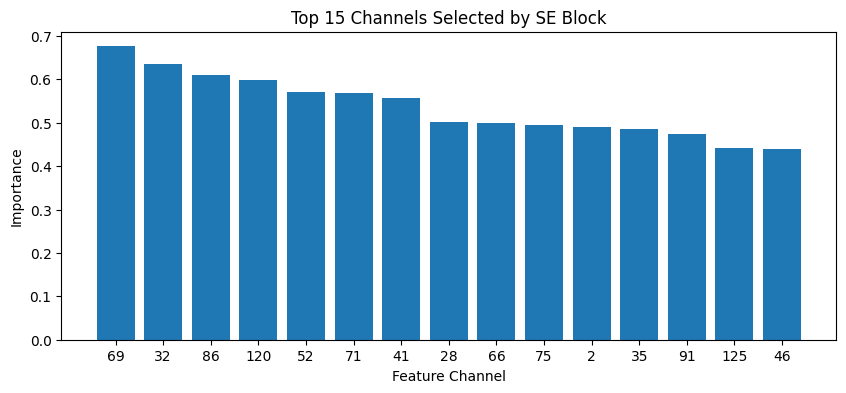

In [ ]:
top = np.argsort(channel_importance)[::-1][:15]

plt.figure(figsize=(10,4))
plt.bar(range(len(top)),
        channel_importance[top])

plt.xticks(range(len(top)),top)

plt.xlabel("Feature Channel")
plt.ylabel("Importance")

plt.title("Top 15 Channels Selected by SE Block")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Attention Output Shape: (1, 250, 128)
Attention Scores Shape: (1, 4, 250, 250)


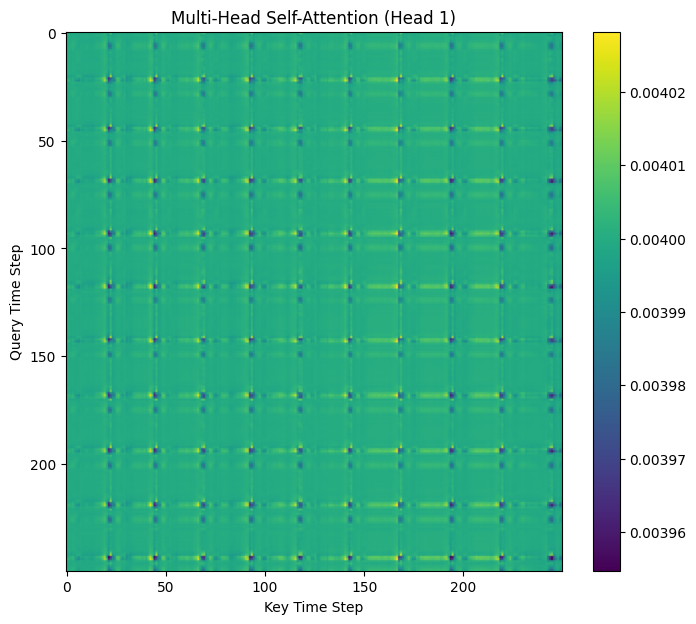

In [ ]:
attention_model = tf.keras.Model(
    inputs=model.input,
    outputs=model.get_layer("multi_head_attention").output
)

# Ensure 'signal' is in the correct batch format (1, 1000, 12)
# 'signal' was already prepared for Grad-CAM in a previous cell
# sample = 0
# signal = np.expand_dims(X_test[sample], axis=0)

attention_output, attention_scores = attention_model.predict(signal)

print("Attention Output Shape:", attention_output.shape)
print("Attention Scores Shape:", attention_scores.shape)

plt.figure(figsize=(8,7))

# Assuming attention_scores is (batch_size, num_heads, sequence_length, sequence_length)
# We'll plot the attention scores for the first head and the first sample in the batch
plt.imshow(
    attention_scores[0,0],
    cmap="viridis",
    aspect="auto"
)

plt.colorbar()

plt.xlabel("Key Time Step")
plt.ylabel("Query Time Step")

plt.title("Multi-Head Self-Attention (Head 1)")

plt.show()

In [ ]:
from scipy.signal import find_peaks
import numpy as np

def detect_r_peaks(signal):
    """
    signal : one ECG lead (1000 samples)
    """

    peaks, _ = find_peaks(
        signal,
        distance=40,        # about 0.4 s at 100 Hz
        prominence=np.std(signal)
    )

    return peaks

In [ ]:
def identify_region(index, r_peaks):

    for r in r_peaks:

        if r-80 <= index <= r-40:
            return "P wave"

        elif r-15 <= index <= r+15:
            return "QRS complex"

        elif r+20 <= index <= r+60:
            return "ST segment"

        elif r+60 <= index <= r+120:
            return "T wave"

    return "Other"

In [ ]:
lead_names = [
    "I","II","III",
    "aVR","aVL","aVF",
    "V1","V2","V3","V4","V5","V6"
]

In [ ]:
def analyse_gradcam(ecg, gradcam):

    explanations=[]

    for lead in range(12):

        signal = ecg[:,lead]

        cam = gradcam[lead]

        r_peaks = detect_r_peaks(signal)

        important = np.where(cam > 0.7*cam.max())[0]

        if len(important)==0:
            continue

        regions=[]

        for idx in important:
            regions.append(
                identify_region(idx,r_peaks)
            )

        region=max(
            set(regions),
            key=regions.count
        )

        explanations.append({

            "lead":lead_names[lead],

            "region":region,

            "importance":cam.max()

        })

    explanations.sort(
        key=lambda x:x["importance"],
        reverse=True
    )

    return explanations

In [ ]:
def generate_report(explanations,
                    prediction,
                    confidence):

    top = explanations[:4]

    text=[]

    text.append(
        f"Prediction: {prediction} ({confidence:.1f}% confidence)\n"
    )

    text.append(
        "The model focused mainly on:\n"
    )

    for item in top:

        text.append(

            f"• {item['region']} in Lead {item['lead']}"

        )

    return "\n".join(text)

In [ ]:
import tensorflow as tf
import numpy as np

def compute_lead_importance(model, sample):

    x = tf.convert_to_tensor(sample[np.newaxis], dtype=tf.float32)

    with tf.GradientTape() as tape:

        tape.watch(x)

        pred = model(x)

        class_idx = tf.argmax(pred[0])

        score = pred[:, class_idx]

    grads = tape.gradient(score, x)

    grads = tf.abs(grads)

    lead_scores = tf.reduce_mean(grads, axis=1)

    return lead_scores.numpy()[0]

In [ ]:
lead_scores = compute_lead_importance(model, sample)

lead_names = [
    "I","II","III",
    "aVR","aVL","aVF",
    "V1","V2","V3","V4","V5","V6"
]

for lead, score in zip(lead_names, lead_scores):
    print(f"{lead:4s}: {score:.5f}")

LookupError: gradient registry has no entry for: shap_BiasAdd

In [ ]:
sample = X_test[0]

pred = model.predict(sample[np.newaxis])[0]

predicted_class = mlb.classes_[np.argmax(pred)]

confidence = pred.max()*100

gradcam = compute_gradcam_all_leads(
    model,
    sample
)

exp = analyse_gradcam(
    sample,
    gradcam
)

print(
    generate_report(
        exp,
        predicted_class,
        confidence
    )
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


NameError: name 'compute_gradcam_all_leads' is not defined